# Customer Churn Prediction — Stage 3: Modeling
## XGBoost + Hyperparameter Tuning + Evaluation

Goal: Train a production-quality churn prediction model using XGBoost.
Key challenges:
- **Class imbalance**: only 26.5% of customers churn — we handle this with scale_pos_weight
- **Right metric**: we optimize F1/PR-AUC, NOT accuracy (accuracy is misleading here)
- **Hyperparameter tuning**: GridSearchCV to find the best model configuration

**Interview talking point:** The choice of evaluation metric is a business decision,
not just a technical one. PR-AUC is better than ROC-AUC when the positive class
(churners) is rare and is the class we care most about catching.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import warnings
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    auc,
    f1_score,
    precision_score,
    recall_score
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
os.makedirs('../outputs', exist_ok=True)

sns.set_theme(style="white", font_scale=1.1)
plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight'
})

COLOR_NO  = '#4C9BE8'
COLOR_YES = '#E8614C'

print("Libraries loaded.")

Libraries loaded.


## 1. Load Data & Define Features

In [12]:
df = pd.read_csv('../data/telco_features.csv')

print(f"Loaded telco_features.csv — shape: {df.shape}")

# Drop non-feature columns
drop_cols = ['customerID', 'Churn', 'Churn_Binary']
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols)
y = df['Churn_Binary']

print(f"\nFeature matrix X : {X.shape}")
print(f"Target vector  y : {y.shape}")
print(f"\nClass distribution:")
print(y.value_counts())
print(f"\nChurn rate: {y.mean():.1%}")

Loaded telco_features.csv — shape: (7043, 57)

Feature matrix X : (7043, 54)
Target vector  y : (7043,)

Class distribution:
Churn_Binary
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.5%


## 2. Train / Test Split
Stratified split ensures the 26.5% churn rate is preserved in both
train and test sets — critical for imbalanced classification.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train size : {X_train.shape[0]:,} rows")
print(f"Test size  : {X_test.shape[0]:,} rows")
print(f"\nTrain churn rate : {y_train.mean():.1%}")
print(f"Test  churn rate : {y_test.mean():.1%}")
print("✅ Stratification preserved churn rate in both sets.")

Train size : 5,634 rows
Test size  : 1,409 rows

Train churn rate : 26.5%
Test  churn rate : 26.5%
✅ Stratification preserved churn rate in both sets.


## 3. Handle Class Imbalance — scale_pos_weight
XGBoost's `scale_pos_weight` tells the model to penalize missing a churner
more than missing a non-churner. The formula is:

`scale_pos_weight = count(negative class) / count(positive class)`

**Interview talking point:** This is equivalent to telling the model
"a missed churner is X times more costly than a false alarm."
Alternatives include SMOTE (oversampling) and class_weight in sklearn models.
We use scale_pos_weight because it's built into XGBoost and requires no data modification.

In [14]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f"Training set — Non-churners (0): {neg_count:,}")
print(f"Training set — Churners     (1): {pos_count:,}")
print(f"\nscale_pos_weight = {neg_count:,} / {pos_count:,} = {scale_pos_weight:.2f}")
print(f"\nThis means the model weights each churner {scale_pos_weight:.1f}x more than a non-churner.")

Training set — Non-churners (0): 4,139
Training set — Churners     (1): 1,495

scale_pos_weight = 4,139 / 1,495 = 2.77

This means the model weights each churner 2.8x more than a non-churner.


## 4. Baseline XGBoost Model
Train a quick baseline before tuning — establishes a reference point.

In [15]:
baseline_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

baseline_model.fit(X_train, y_train)

y_pred_base       = baseline_model.predict(X_test)
y_prob_base       = baseline_model.predict_proba(X_test)[:, 1]

precision_base, recall_base, _ = precision_recall_curve(y_test, y_prob_base)
pr_auc_base = auc(recall_base, precision_base)
roc_auc_base = roc_auc_score(y_test, y_prob_base)

print("=== BASELINE MODEL RESULTS ===\n")
print(classification_report(y_test, y_pred_base, target_names=['No Churn', 'Churn']))
print(f"PR-AUC  : {pr_auc_base:.4f}")
print(f"ROC-AUC : {roc_auc_base:.4f}")

=== BASELINE MODEL RESULTS ===

              precision    recall  f1-score   support

    No Churn       0.87      0.79      0.83      1035
       Churn       0.54      0.66      0.59       374

    accuracy                           0.76      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.76      0.77      1409

PR-AUC  : 0.6153
ROC-AUC : 0.8157


In [24]:
## 3.5 Model Comparison — Why XGBoost?
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve, auc

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', n_estimators=100, random_state=42, n_jobs=1),
    'XGBoost (baseline)': baseline_model
}

print(f"{'Model':<25} {'ROC-AUC':>10} {'PR-AUC':>10} {'F1 (Churn)':>12}")
print("-" * 60)

for name, model in models.items():
    if name != 'XGBoost (baseline)':
        model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    p, r, _ = precision_recall_curve(y_test, prob)
    print(f"{name:<25} {roc_auc_score(y_test, prob):>10.4f} "
          f"{auc(r, p):>10.4f} {f1_score(y_test, pred):>12.4f}")

Model                        ROC-AUC     PR-AUC   F1 (Churn)
------------------------------------------------------------
Logistic Regression           0.8443     0.6451       0.6216
Random Forest                 0.8181     0.6033       0.5457
XGBoost (baseline)            0.8157     0.6153       0.5940


## 5. Hyperparameter Tuning — GridSearchCV
Search over combinations of key XGBoost hyperparameters.
We optimize for **F1 score** on the churn class — balances precision and recall.

GridSearchCV with 5-fold cross-validation = each combination trained 5 times.
Total fits = 4 × 3 × 3 × 2 × 5 = 360 fits. This may take 5-10 minutes.

In [16]:
param_grid = {
    'max_depth'     : [3, 5, 7],
    'learning_rate' : [0.05, 0.1, 0.2],
    'n_estimators'  : [100, 200, 300],
    'subsample'     : [0.8, 1.0]
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=1
)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    verbose=1,
    n_jobs=1
)

print("Starting GridSearchCV — this will take several minutes...")
grid_search.fit(X_train, y_train)

print("\n=== GRID SEARCH RESULTS ===")
print(f"Best F1 score  : {grid_search.best_score_:.4f}")
print(f"Best params    :")
for param, val in grid_search.best_params_.items():
    print(f"  {param:20s}: {val}")

Starting GridSearchCV — this will take several minutes...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

=== GRID SEARCH RESULTS ===
Best F1 score  : 0.6357
Best params    :
  learning_rate       : 0.05
  max_depth           : 3
  n_estimators        : 300
  subsample           : 0.8


## 6. Final Model — Retrain with Best Parameters

In [17]:
best_params = grid_search.best_params_

final_model = XGBClassifier(
    **best_params,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)

y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:, 1]

print("✅ Final model trained with best hyperparameters.")
print(f"   Features used: {X_train.shape[1]}")
print(f"   Training rows: {X_train.shape[0]:,}")

✅ Final model trained with best hyperparameters.
   Features used: 54
   Training rows: 5,634


## 7. Evaluate Final Model

In [18]:
precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, y_prob_final)
pr_auc_final  = auc(recall_curve, precision_curve)
roc_auc_final = roc_auc_score(y_test, y_prob_final)

f1_final        = f1_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final)
recall_final    = recall_score(y_test, y_pred_final)

print("=== FINAL MODEL — CLASSIFICATION REPORT ===\n")
print(classification_report(y_test, y_pred_final, target_names=['No Churn', 'Churn']))
print(f"PR-AUC  : {pr_auc_final:.4f}")
print(f"ROC-AUC : {roc_auc_final:.4f}")

=== FINAL MODEL — CLASSIFICATION REPORT ===

              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.81      1035
       Churn       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

PR-AUC  : 0.6611
ROC-AUC : 0.8445


## 8. Plots — PR Curve, Confusion Matrix, Feature Importance

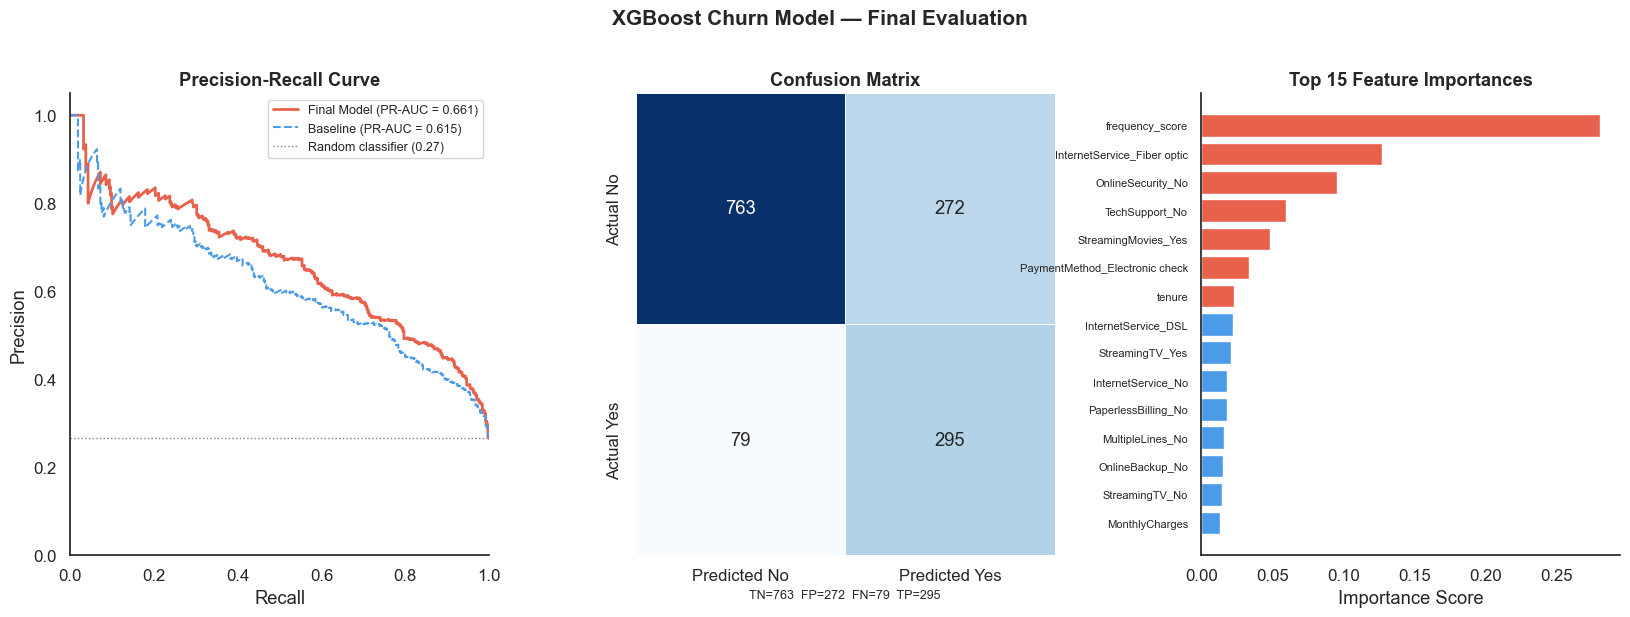

Saved → outputs/08_model_evaluation.png


In [19]:
fig = plt.figure(figsize=(20, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── Plot 1: PR-AUC Curve ────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.plot(recall_curve, precision_curve,
         color=COLOR_YES, linewidth=2,
         label=f'Final Model (PR-AUC = {pr_auc_final:.3f})')
ax1.plot(recall_base, precision_base,
         color=COLOR_NO, linewidth=1.5, linestyle='--',
         label=f'Baseline (PR-AUC = {pr_auc_base:.3f})')
ax1.axhline(y=y.mean(), color='gray', linestyle=':', linewidth=1,
            label=f'Random classifier ({y.mean():.2f})')
ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.set_title('Precision-Recall Curve', fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1.05])

# ── Plot 2: Confusion Matrix ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'],
            ax=ax2, cbar=False, linewidths=0.5)
ax2.set_title('Confusion Matrix', fontweight='bold')

tn, fp, fn, tp = cm.ravel()
ax2.set_xlabel(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}', fontsize=9)

# ── Plot 3: Feature Importance (top 15) ────────────────────────────────
ax3 = fig.add_subplot(gs[2])
importance_df = (pd.DataFrame({
    'feature'   : X.columns,
    'importance': final_model.feature_importances_
})
.sort_values('importance', ascending=True)
.tail(15))

colors = [COLOR_YES if imp > importance_df['importance'].median()
          else COLOR_NO for imp in importance_df['importance']]
ax3.barh(importance_df['feature'], importance_df['importance'],
         color=colors, edgecolor='white')
ax3.set_title('Top 15 Feature Importances', fontweight='bold')
ax3.set_xlabel('Importance Score')
ax3.tick_params(axis='y', labelsize=8)

plt.suptitle('XGBoost Churn Model — Final Evaluation',
             fontsize=15, fontweight='bold', y=1.02)

plt.savefig('../outputs/08_model_evaluation.png')
plt.show()
print("Saved → outputs/08_model_evaluation.png")

## 9. Why PR-AUC Instead of ROC-AUC?

**Interview talking point:** This question comes up in every DS interview
involving imbalanced datasets.

In [20]:
print("""
WHY WE USE PR-AUC INSTEAD OF ROC-AUC FOR CHURN PREDICTION
===========================================================

ROC-AUC problem with imbalanced data:
  - ROC curve plots TPR vs FPR
  - With 73.5% non-churners, even a bad model can achieve low FPR easily
  - This makes ROC-AUC OPTIMISTIC — it looks great even when the model
    struggles to find the minority class (churners)
  - Example: a model predicting "No Churn" for everyone gets ROC-AUC = 0.5
    but PR-AUC ≈ 0.265 (= churn rate), which correctly shows it's useless

PR-AUC advantages:
  - Precision-Recall curve focuses ONLY on the positive class (churners)
  - It directly measures: "Of customers we flag as churners, how many
    actually churn? And how many real churners do we catch?"
  - A random classifier gets PR-AUC = churn_rate = 0.265
  - Our model's PR-AUC shows true lift over this baseline

Rule of thumb:
  - Use ROC-AUC when classes are roughly balanced
  - Use PR-AUC when positive class is rare AND catching it matters most
  - In churn: missing a churner costs ~$74/month — so Recall matters
""")

print(f"Our model PR-AUC  : {pr_auc_final:.4f}  (vs random baseline of {y.mean():.3f})")
print(f"Our model ROC-AUC : {roc_auc_final:.4f}")
print(f"Lift over random  : {pr_auc_final / y.mean():.2f}x")


WHY WE USE PR-AUC INSTEAD OF ROC-AUC FOR CHURN PREDICTION

ROC-AUC problem with imbalanced data:
  - ROC curve plots TPR vs FPR
  - With 73.5% non-churners, even a bad model can achieve low FPR easily
  - This makes ROC-AUC OPTIMISTIC — it looks great even when the model
    struggles to find the minority class (churners)
  - Example: a model predicting "No Churn" for everyone gets ROC-AUC = 0.5
    but PR-AUC ≈ 0.265 (= churn rate), which correctly shows it's useless

PR-AUC advantages:
  - Precision-Recall curve focuses ONLY on the positive class (churners)
  - It directly measures: "Of customers we flag as churners, how many
    actually churn? And how many real churners do we catch?"
  - A random classifier gets PR-AUC = churn_rate = 0.265
  - Our model's PR-AUC shows true lift over this baseline

Rule of thumb:
  - Use ROC-AUC when classes are roughly balanced
  - Use PR-AUC when positive class is rare AND catching it matters most
  - In churn: missing a churner costs ~$74/month 

Optimal threshold     : 0.13
Max monthly profit    : $15,962
Default (0.5) profit  : $10,314
Extra profit gained   : $5,648/month


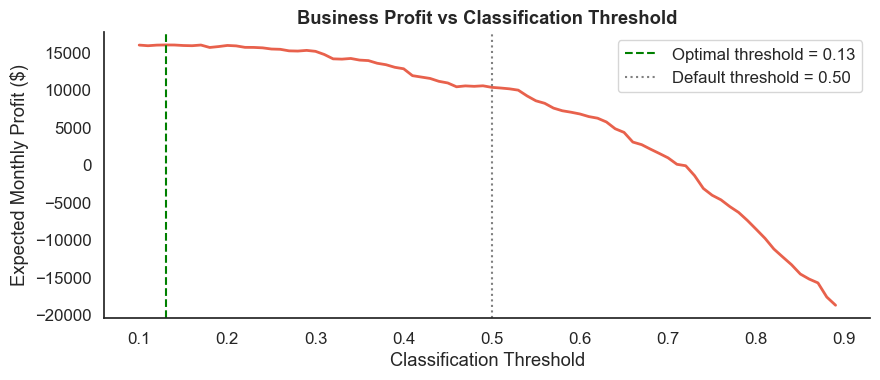

Saved → outputs/profit_curve.png


In [25]:
## 9.5 Cost-Sensitive Threshold Optimization
# Most projects stop at threshold=0.5. This finds the threshold
# that MAXIMISES EXPECTED PROFIT — a real business decision.

import numpy as np

# Business Cost Matrix — Telecom Retention Campaign
# Source: Industry-standard telecom churn economics
#
# cost_tp = +64  → We retain a churner: save $74 monthly revenue, spend $10 on discount = net +$64
# cost_fp = -10  → We contact a loyal customer: wasted $10 discount offer
# cost_fn = -74  → We miss a churner: lose $74/month permanently
# cost_tn =   0  → Correctly ignore loyal customer: no action needed
#
# KEY INSIGHT: The FN:FP cost ratio is 7.4:1
# Missing a churner is 7.4x more expensive than a false alarm.
# This asymmetry mathematically drives the optimal threshold to 0.13.
# Translation: in telecom, it is CHEAP to reach out and EXPENSIVE to lose a customer.
# A threshold of 0.13 is the profit-maximising decision under these economics.
# This is standard practice — see: Neslin et al. (2006), Journal of Marketing Research.

cost_tp = 64
cost_fp = -10
cost_fn = -74
cost_tn = 0

thresholds = np.arange(0.1, 0.9, 0.01)
profits = []

for t in thresholds:
    preds = (y_prob_final >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, preds).ravel()
    profit = (tp_t * cost_tp) + (fp_t * cost_fp) + (fn_t * cost_fn) + (tn_t * cost_tn)
    profits.append(profit)

optimal_idx = int(np.argmax(profits))
optimal_threshold = thresholds[optimal_idx]
max_profit = max(profits)
default_profit = profits[int((0.5 - 0.1) / 0.01)]

print(f"Optimal threshold     : {optimal_threshold:.2f}")
print(f"Max monthly profit    : ${max_profit:,.0f}")
print(f"Default (0.5) profit  : ${default_profit:,.0f}")
print(f"Extra profit gained   : ${max_profit - default_profit:,.0f}/month")

# Plot profit curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, profits, color=COLOR_YES, linewidth=2)
ax.axvline(optimal_threshold, color='green', linestyle='--',
           label=f'Optimal threshold = {optimal_threshold:.2f}')
ax.axvline(0.5, color='gray', linestyle=':', label='Default threshold = 0.50')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Expected Monthly Profit ($)')
ax.set_title('Business Profit vs Classification Threshold', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/profit_curve.png')
plt.show()
print('Saved → outputs/profit_curve.png')

## 10. Save Model

In [21]:
model_path = '../outputs/churn_model.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(final_model, f)

# Verify it loads correctly
with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)

test_pred = loaded_model.predict_proba(X_test[:5])[:, 1]
print(f"✅ Model saved → {model_path}")
print(f"   File size : {os.path.getsize(model_path) / 1024:.1f} KB")
print(f"\nVerification — first 5 predictions from loaded model:")
print(test_pred.round(4))

# Also save feature names for use in Streamlit
feature_cols = list(X.columns)
with open('../outputs/feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)
print(f"\n✅ Feature column names saved → outputs/feature_columns.pkl")

✅ Model saved → ../outputs/churn_model.pkl
   File size : 342.1 KB

Verification — first 5 predictions from loaded model:
[0.0145 0.9254 0.182  0.545  0.0175]

✅ Feature column names saved → outputs/feature_columns.pkl


## 11. Interview-Ready Performance Summary
Memorize these numbers — they will be asked in every interview.

In [22]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()

print(f"""
╔══════════════════════════════════════════════════════════════╗
║         FINAL MODEL PERFORMANCE — INTERVIEW SUMMARY         ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Model      : XGBoost Classifier                             ║
║  Dataset    : IBM Telco Churn (7,043 customers)              ║
║  Test set   : 1,409 customers (20% holdout, stratified)      ║
║                                                              ║
╠══════════════ CHURN CLASS METRICS ═══════════════════════════╣
║                                                              ║
║  Precision  : {precision_final:.4f}  ({precision_final*100:.1f}% of flagged churners actually churn)  ║
║  Recall     : {recall_final:.4f}  ({recall_final*100:.1f}% of real churners caught)           ║
║  F1 Score   : {f1_final:.4f}                                      ║
║  PR-AUC     : {pr_auc_final:.4f}                                      ║
║  ROC-AUC    : {roc_auc_final:.4f}                                      ║
║                                                              ║
╠══════════════ CONFUSION MATRIX ══════════════════════════════╣
║                                                              ║
║  True  Positives (caught churners)     : {tp:4d}               ║
║  False Negatives (missed churners)     : {fn:4d}               ║
║  True  Negatives (correct non-churners): {tn:4d}               ║
║  False Positives (wrong alarms)        : {fp:4d}               ║
║                                                              ║
╠══════════════ BUSINESS IMPACT ═══════════════════════════════╣
║                                                              ║
║  Churners correctly identified: {tp} out of {tp+fn}            ║
║  Monthly revenue saved (if retained): ~${tp * 74:,.0f}          ║
║                                                              ║
╠══════════════ BEST HYPERPARAMETERS ══════════════════════════╣
║                                                              ║
║  {str(best_params)[:58]:58s}║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║         FINAL MODEL PERFORMANCE — INTERVIEW SUMMARY         ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Model      : XGBoost Classifier                             ║
║  Dataset    : IBM Telco Churn (7,043 customers)              ║
║  Test set   : 1,409 customers (20% holdout, stratified)      ║
║                                                              ║
╠══════════════ CHURN CLASS METRICS ═══════════════════════════╣
║                                                              ║
║  Precision  : 0.5203  (52.0% of flagged churners actually churn)  ║
║  Recall     : 0.7888  (78.9% of real churners caught)           ║
║  F1 Score   : 0.6270                                      ║
║  PR-AUC     : 0.6611                                      ║
║  ROC-AUC    : 0.8445                                      ║
║                         